In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


2026-02-24 17:39:13.152607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771954753.359976      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771954753.418806      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771954753.933434      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771954753.933490      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771954753.933494      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# Load RAW data
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

# Bảo vệ chống double normalize
assert x_train_raw.dtype == np.uint8 and x_train_raw.max() == 255, "❌ Data không phải uint8 gốc!"

# Normalize đúng 1 lần — biến _n = đã normalize, _raw = chưa normalize
x_train_n = x_train_raw.astype("float32") / 255.0
x_test_n  = x_test_raw.astype("float32")  / 255.0
y_train_s = y_train_raw.squeeze().astype("int32")
y_test_s  = y_test_raw.squeeze().astype("int32")

# Xoá raw để tránh nhầm về sau
del x_train_raw, x_test_raw, y_train_raw, y_test_raw

print(f"x_train_n : shape={x_train_n.shape}, min={x_train_n.min():.3f}, max={x_train_n.max():.3f}")
print(f"x_test_n  : shape={x_test_n.shape},  min={x_test_n.min():.3f},  max={x_test_n.max():.3f}")
# Expected: min=0.000, max=1.000


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
x_train_n : shape=(50000, 32, 32, 3), min=0.000, max=1.000
x_test_n  : shape=(10000, 32, 32, 3),  min=0.000,  max=1.000


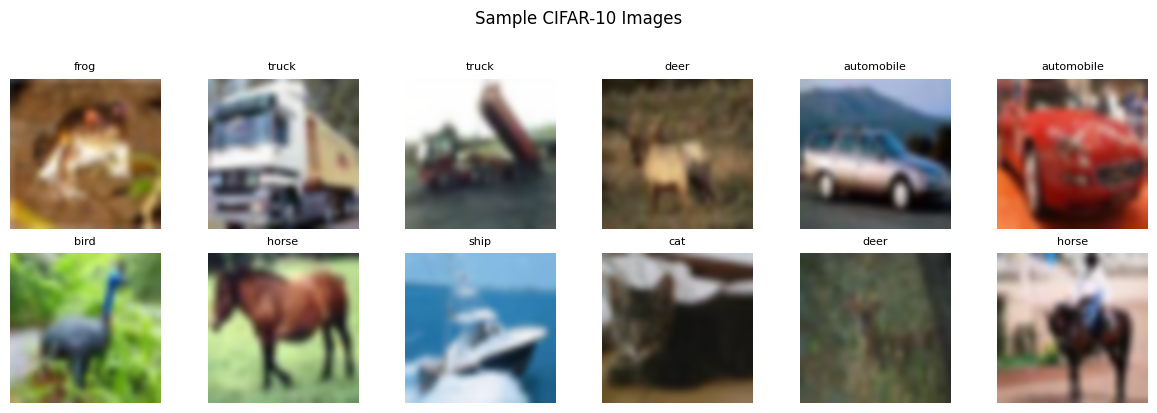

In [3]:
CLASS_NAMES = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

plt.figure(figsize=(12, 4))
for i in range(12):
    plt.subplot(2, 6, i+1)
    plt.imshow(np.clip(x_train_n[i], 0, 1), interpolation="bicubic")
    plt.title(CLASS_NAMES[y_train_s[i]], fontsize=8)
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Images", y=1.02)
plt.tight_layout()
plt.show()


In [4]:
AUTOTUNE   = tf.data.AUTOTUNE
BATCH_SIZE = 128
NUM_VAL    = 5000
NUM_TRAIN  = 50000 - NUM_VAL   # 45000

full_ds  = tf.data.Dataset.from_tensor_slices((x_train_n, y_train_s))
val_ds   = full_ds.take(NUM_VAL) \
                  .batch(BATCH_SIZE).prefetch(AUTOTUNE)
train_ds = full_ds.skip(NUM_VAL) \
                  .shuffle(NUM_TRAIN, seed=42) \
                  .batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((x_test_n, y_test_s)) \
                          .batch(BATCH_SIZE).prefetch(AUTOTUNE)

STEPS_PER_EPOCH = len(train_ds)

# Verify pipeline
for imgs, lbls in test_ds.take(1):
    print(f"test_ds batch: shape={imgs.shape}, min={imgs.numpy().min():.4f}, max={imgs.numpy().max():.4f}")
    # Expected max ≈ 1.0

print(f"Train batches : {len(train_ds)}")
print(f"Val   batches : {len(val_ds)}")
print(f"Test  batches : {len(test_ds)}")


I0000 00:00:1771954789.132826      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771954789.138965      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


test_ds batch: shape=(128, 32, 32, 3), min=0.0000, max=1.0000
Train batches : 352
Val   batches : 40
Test  batches : 79


In [5]:
NUM_CLASSES    = 10
L2_WEIGHT_DECAY = 1e-4

# Augmentation: Pad 4px → RandomCrop 32x32 → RandomFlip
data_augmentation = tf.keras.Sequential([
    layers.ZeroPadding2D(padding=(4, 4)),
    layers.RandomCrop(height=32, width=32),
    layers.RandomFlip("horizontal"),
], name="augment")

def resnet_v2_block(x, filters, stride=1, use_projection=False):
    """Pre-activation Residual Block (ResNet-v2)"""
    # Pre-activation
    preact = layers.BatchNormalization()(x)
    preact = layers.Activation("relu")(preact)

    # Projection shortcut nếu thay đổi dimension
    if use_projection:
        shortcut = layers.Conv2D(
            filters, 1, strides=stride,
            kernel_regularizer=regularizers.l2(L2_WEIGHT_DECAY),
            use_bias=False
        )(preact)
    else:
        shortcut = x

    # Main path
    y = layers.Conv2D(
        filters, 3, strides=stride, padding="same",
        kernel_regularizer=regularizers.l2(L2_WEIGHT_DECAY),
        use_bias=False
    )(preact)
    y = layers.BatchNormalization()(y)
    y = layers.Activation("relu")(y)
    y = layers.Conv2D(
        filters, 3, strides=1, padding="same",
        kernel_regularizer=regularizers.l2(L2_WEIGHT_DECAY),
        use_bias=False
    )(y)

    return layers.Add()([shortcut, y])

def build_custom_resnet():
    inputs = layers.Input(shape=(32, 32, 3))
    x = data_augmentation(inputs)

    # Stem
    x = layers.Conv2D(
        16, 3, padding="same",
        kernel_regularizer=regularizers.l2(L2_WEIGHT_DECAY),
        use_bias=False
    )(x)

    # Stage 1: 32×32, channels=16
    x = resnet_v2_block(x, 16, use_projection=False)
    x = resnet_v2_block(x, 16)
    x = resnet_v2_block(x, 16)

    # Stage 2: 16×16, channels=32
    x = resnet_v2_block(x, 32, stride=2, use_projection=True)
    x = resnet_v2_block(x, 32)
    x = resnet_v2_block(x, 32)

    # Stage 3: 8×8, channels=64
    x = resnet_v2_block(x, 64, stride=2, use_projection=True)
    x = resnet_v2_block(x, 64)
    x = resnet_v2_block(x, 64)

    # Final BN + ReLU (bắt buộc với ResNet-v2)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Classifier head
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(
        NUM_CLASSES, activation="softmax",
        kernel_regularizer=regularizers.l2(L2_WEIGHT_DECAY)
    )(x)

    return models.Model(inputs, outputs)


In [6]:
EPOCHS       = 80
TOTAL_STEPS  = EPOCHS * STEPS_PER_EPOCH
WARMUP_STEPS = 5 * STEPS_PER_EPOCH

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps, alpha=0.01):
        self.base_lr      = base_lr
        self.total_steps  = total_steps
        self.warmup_steps = warmup_steps
        self.alpha        = alpha

    def __call__(self, step):
        step      = tf.cast(step, tf.float32)
        warmup_lr = self.base_lr * (step / self.warmup_steps)
        progress  = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        cosine_lr = self.base_lr * (
            self.alpha + (1 - self.alpha) * 0.5 * (1.0 + tf.cos(3.14159265 * progress))
        )
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            "base_lr"     : self.base_lr,
            "total_steps" : self.total_steps,
            "warmup_steps": self.warmup_steps,
            "alpha"       : self.alpha
        }

lr_schedule = WarmupCosineDecay(
    base_lr      = 2e-3,
    total_steps  = TOTAL_STEPS,
    warmup_steps = WARMUP_STEPS,
    alpha        = 0.01
)
print(f"Steps/epoch : {STEPS_PER_EPOCH}")
print(f"Total steps : {TOTAL_STEPS}")
print(f"LR epoch 1  : {float(lr_schedule(0)):.6f}")
print(f"LR epoch 5  : {float(lr_schedule(5 * STEPS_PER_EPOCH)):.6f}")
print(f"LR epoch 80 : {float(lr_schedule(TOTAL_STEPS)):.6f}")


Steps/epoch : 352
Total steps : 28160
LR epoch 1  : 0.000000
LR epoch 5  : 0.002000
LR epoch 80 : 0.000020


In [7]:
strategy = tf.distribute.MirroredStrategy()
print(f"Số GPU đang dùng: {strategy.num_replicas_in_sync}")

with strategy.scope():
    model = build_custom_resnet()
    model.compile(
        optimizer = tf.keras.optimizers.Adam(
            learning_rate = lr_schedule,
            weight_decay  = L2_WEIGHT_DECAY
        ),
        loss    = tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics = ["accuracy"]
    )

model.summary()


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Số GPU đang dùng: 2


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augment             │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        432 │ augment[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      2,304 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      2,304 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ conv2d[0][0],     │
│                     │ 16)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ add[0][0]         │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      2,304 │ activation_2[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      2,304 │ activation_3[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ add[0][0],      

 Total params: 273,658 (1.04 MB)

 Trainable params: 272,282 (1.04 MB)

 Non-trainable params: 1,376 (5.38 KB)

In [8]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_resnet20_cifar.keras",
        monitor        = "val_accuracy",
        save_best_only = True,
        verbose        = 1
    ),
    tf.keras.callbacks.LambdaCallback(
        on_epoch_end = lambda epoch, logs: print(
            f"  → LR: {float(lr_schedule(epoch * STEPS_PER_EPOCH)):.6f}"
        )
    ),
    tf.keras.callbacks.CSVLogger("/kaggle/working/training_log.csv")
]

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    callbacks       = callbacks
)


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1771954813.148278      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771954813.148290      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1970 - loss: 2.2154INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_accuracy improved from -inf to 0.20560, saving model to /kaggle/working/best_resnet20_cifar.keras
  → LR: 0.000000
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.1972 - loss: 2.2147 - val_accuracy: 0.2056 - val_loss: 2.5891
Epoch 2/80
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4595 - loss: 1.5468
Epoch 2: val_accuracy improved from 0.20560 to 0.36880, saving model to /kaggle/working/best_resnet20_cifar.keras
  → LR: 0.000400
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.4597 - loss: 1.5464 - val_accuracy: 0.3688 - val_loss: 1.9985
Epoch 3/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accur


Test Loss    : 0.4135
Test Accuracy: 90.52%

Classification Report:
              precision    recall  f1-score   support

    airplane       0.89      0.92      0.91      1000
  automobile       0.96      0.95      0.96      1000
        bird       0.87      0.87      0.87      1000
         cat       0.84      0.78      0.81      1000
        deer       0.88      0.91      0.89      1000
         dog       0.86      0.85      0.86      1000
        frog       0.93      0.94      0.93      1000
       horse       0.94      0.94      0.94      1000
        ship       0.94      0.96      0.95      1000
       truck       0.94      0.94      0.94      1000

    accuracy                           0.91     10000
   macro avg       0.90      0.91      0.90     10000
weighted avg       0.90      0.91      0.90     10000



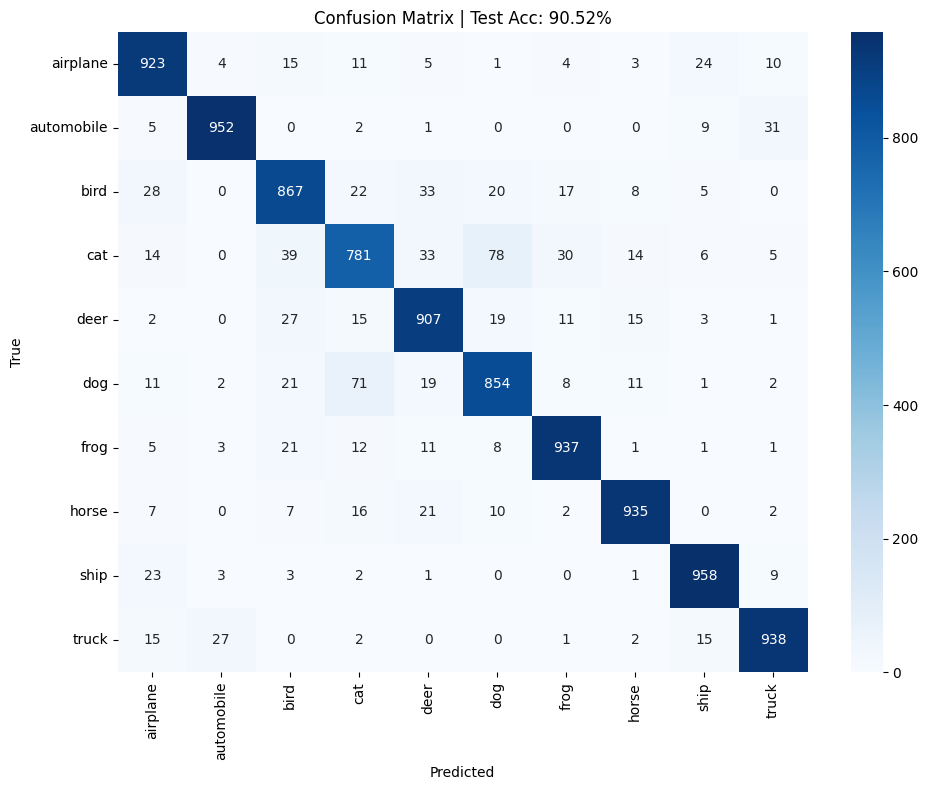

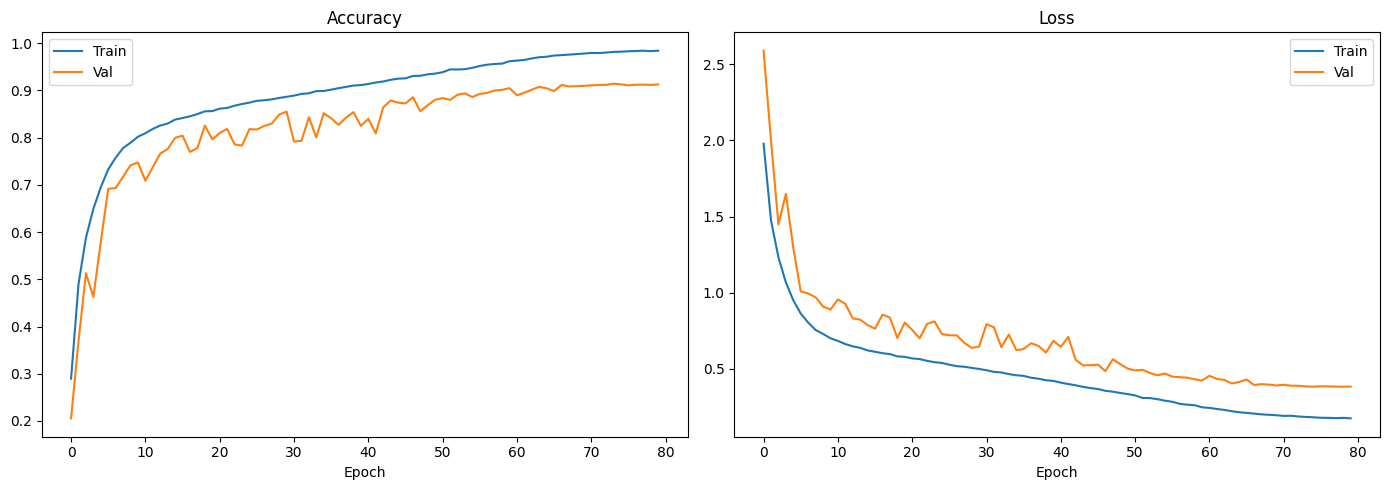

In [9]:
# Load best checkpoint
best_model = tf.keras.models.load_model(
    "/kaggle/working/best_resnet20_cifar.keras",
    custom_objects={"WarmupCosineDecay": WarmupCosineDecay}
)

test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_pred = np.argmax(best_model.predict(test_ds, verbose=0), axis=1)
print("\nClassification Report:")
print(classification_report(y_test_s, y_pred, target_names=CLASS_NAMES))

# ── Confusion Matrix ─────────────────────────────
cm = confusion_matrix(y_test_s, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Confusion Matrix | Test Acc: {test_acc*100:.2f}%")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()

# ── Learning Curve ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["accuracy"],     label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].set_xlabel("Epoch")
axes[1].plot(history.history["loss"],     label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss"); axes[1].legend(); axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig("/kaggle/working/learning_curve.png", dpi=150)
plt.show()


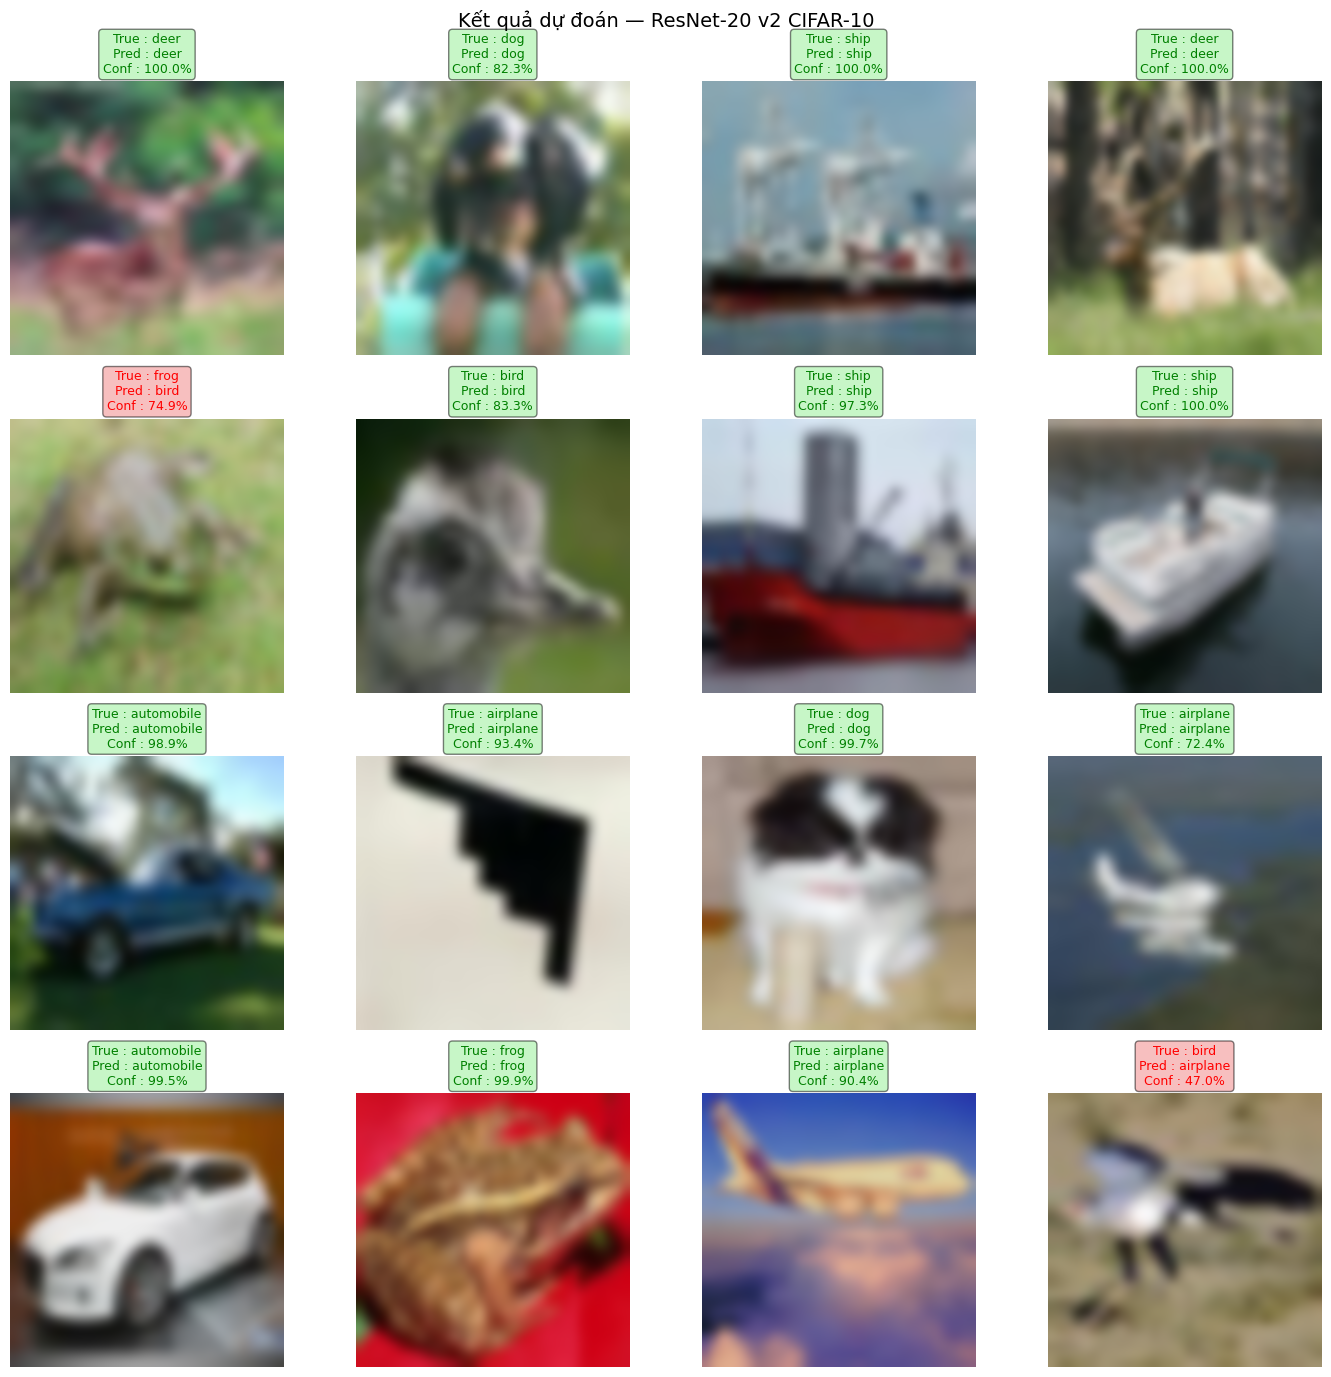

Sample accuracy: 14/16 = 87.5%


In [10]:
# Lấy thẳng từ x_test_n (numpy array) — tránh bug MirroredStrategy
indices          = random.sample(range(len(x_test_n)), 16)
sample_images_np = x_test_n[indices]
sample_labels_np = y_test_s[indices]

probs = best_model.predict(sample_images_np, verbose=0)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle("Kết quả dự đoán — ResNet-20 v2 CIFAR-10", fontsize=14)

for i in range(16):
    ax         = axes[i // 4][i % 4]
    true_label = int(sample_labels_np[i])
    pred_label = int(np.argmax(probs[i]))
    confidence = float(probs[i][pred_label]) * 100
    is_correct = pred_label == true_label

    ax.imshow(np.clip(sample_images_np[i], 0, 1), interpolation="bicubic")
    ax.axis("off")
    ax.set_title(
        f"True : {CLASS_NAMES[true_label]}\n"
        f"Pred : {CLASS_NAMES[pred_label]}\n"
        f"Conf : {confidence:.1f}%",
        fontsize=9,
        color="green" if is_correct else "red",
        bbox=dict(
            boxstyle  = "round,pad=0.3",
            facecolor = "lightgreen" if is_correct else "lightcoral",
            alpha     = 0.5
        )
    )

plt.tight_layout()
plt.savefig("/kaggle/working/sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

correct = np.sum(np.argmax(probs, axis=1) == sample_labels_np)
print(f"Sample accuracy: {correct}/16 = {correct/16*100:.1f}%")
